# Grain structure pairing for morphological representativeness
Given two sets of MCGS grain structures, onw target set and the other sample set, we shall assess the morphological representativeness of every (target GS, sample GS) pair possible, using the network based approach.

In [5]:
import numpy as np
from upxo.repqual.grain_network_repr_assesser import KREPR
import matplotlib.pyplot as plt

# Generate the target and sample GS sets to begin with.
- We shall use the class method **from_gsgen** of **KREPR** class from the **grain_netwrok_assesser** module.
- We shall use Monte-Carlo GS for both TGT and SMP GS sets
- We can use the same TGT GS set to find out whether which GS elements of TGT set are representative to which other GS elements of same TGT set. You can set this with *is_smp_same_as_tgt*.
- Both *characterize_tgt* and *characterize_smp* are set to True, as we need to characterise TGT and SMP GS sets.
- specify which excel input dashboard file to use for GS gen in *tgt_dashboard* and *smp_dashboard*.
- Specify the neighbour orders to use as a list in *ordern*. We will use orders 1, 3 and 5.
- Then we got to specify the grain structure ids to use. As in the present case, we are generating the GS and loading them, and also that we like to only use a few of them, we will explicitly specify them in the next input. Hence we specify *tsid_source* and *ssid_source* as `user`.
- now that *tsid_source* and *ssid_source* are set as `user`, we will now specify, the IDs to use, through *tid* and *sid*.

In [6]:
gstype_tgt = 'mcgs2d'
gstype_smp = 'mcgs2d'
is_smp_same_as_tgt = False
characterize_tgt = True
characterize_smp = True
tgt_dashboard = 'mcgs2d_100x100_m50_q10_mcalg201.xls'
smp_dashboard = 'mcgs2d_100x100_m50_q10_mcalg201.xls'
ordern = [1, 2, 5]
tsid_source = 'user'
ssid_source = 'user'
tid = np.arange(10, 40, 2)
sid = np.arange(10, 40, 2)

In [7]:
kr = KREPR.from_gsgen(gstype_tgt=gstype_tgt,
                      gstype_smp=gstype_smp,
                      is_smp_same_as_tgt=is_smp_same_as_tgt,
                      characterize_tgt=characterize_tgt,
                      characterize_smp=characterize_smp,
					  tgt_dashboard=tgt_dashboard,
					  smp_dashboard=smp_dashboard,
					  ordern=ordern,
                      tsid_source=tsid_source, ssid_source=ssid_source,
					  tid=tid, 
                      sid=sid)

GENERATING TARGET GRAIN STRUCTURES
c:\development\m2matmod\upxo_packaged\upxo_private\src\upxo\interfaces\user_inputs
c:\development\m2matmod\upxo_packaged\upxo_private\src\upxo\interfaces\user_inputs\mcgs2d_100x100_m50_q10_mcalg201.xls
Algo_hops details
(('201.0', 100),)
[False]





 Initiating Monte-Carlo simulation
     xmin, xmax, xinc: 0.0, 100.0, 1.0
     ymin, ymax, yinc: 0.0, 100.0, 1.0
     zmin, zmax, zinc: 0.0, 50.0, 1.0
     No. of states: 10
     Dimensionality: 2
     Algorithm: 201.0 





########################################
201.0
########################################
Using ALG-200: SA's SL NL-1 TP1 C2 unweighted Q-Pott's model:
|--------------- MC SIM RUN IN PROGRESS on: ALG200---------------|
GS temporal slice 0 stored
 ..............................
GS temporal slice 1 stored
 ..............................
GS temporal slice 2 stored
 ..............................
GS temporal slice 3 stored
 ..............................
GS temporal slice 4 stored
 ........

# Set up the network representativeness field
Set rkf field calculation flags and initiate rkf dict accordingly. We will need the following Boolean input parameters.
* js. Jaccard similarity measure of representativeness MOR.
* wd. Wasserstein distance MOR.
* ksp. K-S test P-value MOR.
* ed. Energy distance MOR.
* nlsd. NetLSD similarity MOR.
* degcen. Degree Centrality. Suggests how connected each grain is.
* btwcen. Betweenness Centrality. Suggests how important a grain is in connecting others.
* egnvcen. Eigenvector Centrality. Suggests how influential a grain is within the network.

Here, we shall inly look at *js*, *wd*, *ksp*, *ed* and *nlsd*.

In [8]:
kr.set_rkf(js=True, wd=True, ksp=True, ed=True, nlsd=True,
           degcen=False, btwcen=False, clscen=False, egnvcen=False)

----------------------------------------
Creating R-field data structures.


# Calculate the field
Contains network (k) based R-Field (i.e. rkf) data. Thi smust be set before representativeness assessment is done.
- **prop** means proprty parameter to be used. We will use network degree, i.e. `kdegree` for this. Please refer documentation for other options which you could provide fort `prop`.

In [9]:
kr.calculate_rkf(prop='kdegree')

++++++++++++++++++++++++++++++++++++++
[1, 2, 5] -------------
++++++++++++++++++++++++++++++++++++++
----------------------------------------
Calculating R-field.
     O(n): 1, gsID pair: (10-20)
     O(n): 1, gsID pair: (20-20)
     O(n): 1, gsID pair: (30-20)
----------------------------------------
Calculating R-field.
     O(n): 2, gsID pair: (10-20)
     O(n): 2, gsID pair: (20-20)
     O(n): 2, gsID pair: (30-20)
----------------------------------------
Calculating R-field.
     O(n): 5, gsID pair: (10-20)
     O(n): 5, gsID pair: (20-20)
     O(n): 5, gsID pair: (30-20)


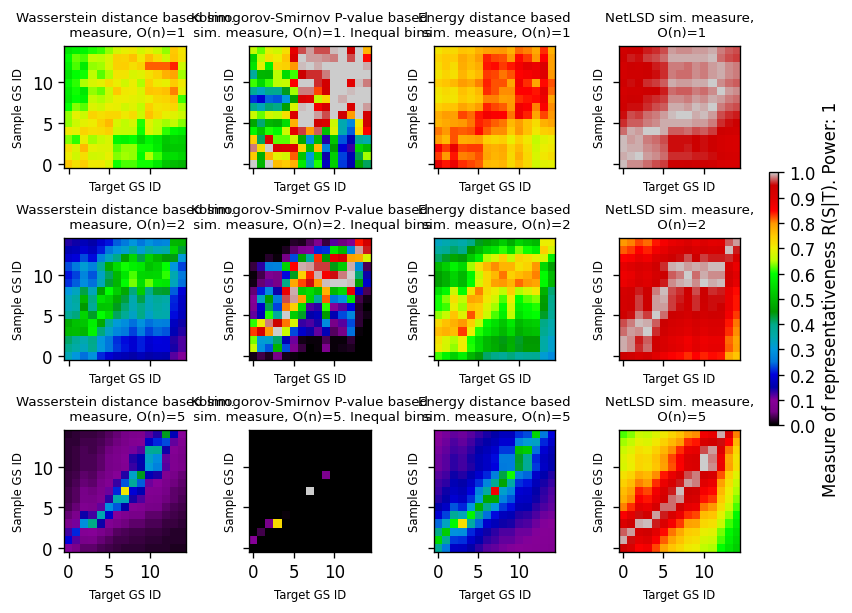

In [11]:
kr.plot_rkf(neigh_orders=ordern, 
            power=1, figsize=(7, 5), dpi=120,
            xtick_incr=5, ytick_incr=5, lfs=7, tfs=8,
            cmap='nipy_spectral', cbarticks=np.arange(0, 1.1, 0.1), cbfs=10,
            cbtitle='Measure of representativeness R(S|T)',
            cbfraction=0.046, cbpad=0.04, cbaspect=30, shrink=0.5,
            cborientation='vertical',
            flags={'rkf_js': False, 'rkf_wd': True,
                   'rkf_ksp': True, 'rkf_ed': True,
                   'rkf_nlsd': True, 'rkf_degcen': False,
                   'rkf_btwcen': False, 'rkf_clscen': False,
                   'rkf_egnvcen': False})

In [13]:
data_title = 'R-Field measure: Energy Distance'
n_bins = 5
AD, AX = kr.calculate_uncertainty_angdist(rkf_measure='ed',
                                          neigh_orders=ordern, n_bins=n_bins,
                                          data_title=data_title,
                                          throw=True, plot_ad=False)

Calculating uncertainty measure: Ang. Dist. for ed at O(n): 1
....U(RKF: ed) at O(1): bin 0/5 
....U(RKF: ed) at O(1): bin 1/5 
....U(RKF: ed) at O(1): bin 2/5 
....U(RKF: ed) at O(1): bin 3/5 
....U(RKF: ed) at O(1): bin 4/5 
Calculating uncertainty measure: Ang. Dist. for ed at O(n): 2
....U(RKF: ed) at O(2): bin 0/5 
....U(RKF: ed) at O(2): bin 1/5 
....U(RKF: ed) at O(2): bin 2/5 
....U(RKF: ed) at O(2): bin 3/5 
....U(RKF: ed) at O(2): bin 4/5 
Calculating uncertainty measure: Ang. Dist. for ed at O(n): 5
....U(RKF: ed) at O(5): bin 0/5 
....U(RKF: ed) at O(5): bin 1/5 
....U(RKF: ed) at O(5): bin 2/5 
....U(RKF: ed) at O(5): bin 3/5 
....U(RKF: ed) at O(5): bin 4/5 


<AxesSubplot: xlabel='R-Field measure: Energy Distance', ylabel='Uncertainty (Mean angular distance), @Iso-R-bins, radians'>

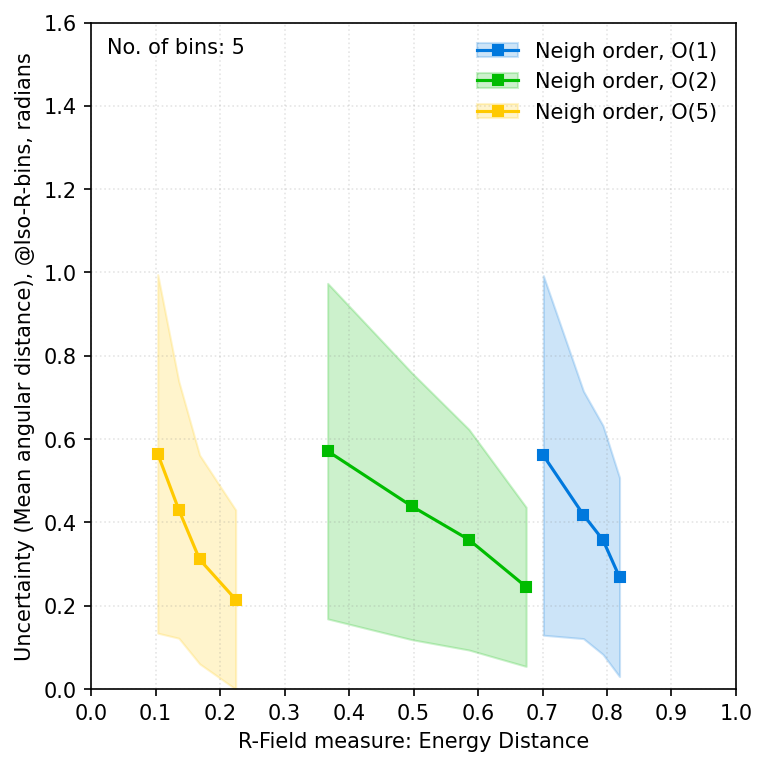

In [14]:
kr.plot_ang_dist(AD, neigh_orders=ordern, n_bins=n_bins,
                 figsize=(5, 5), dpi=150, data_title=data_title,
                 cmap='nipy_spectral')

# EXPLANATIONS

## Data access

### Acccessing individual grain structures

In [15]:
# kr.tgset and kr.sgset give target and sample GS sets as dictionaries. 
print(type(kr.tgset), ' and ', type(kr.sgset))  # 1
print('Target grain structure instance --> ', kr.tgset[1])

<class 'dict'>  and  <class 'dict'>
Target grain structure instance -->  grains :: att : n, lgi, id, ind, spart


In [16]:
dir(kr.tgset[1])

['AF_bgrains_igrains',
 'EAPGLB',
 'EASGLB',
 'EPS',
 'S',
 '__att__',
 '__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gi__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__next1__',
 '__next__',
 '__ori_assign_status_slice__',
 '__ori_assign_status_stack__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__resolution_state__',
 '__setattr__',
 '__setup__positions__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '_check_lgi_dtype_uint8',
 '_gid_bf_merger_',
 '_mcgs2_grain_structure__make_linear_grid',
 '_mcgs2_grain_structure__maxGridSizeToIgnoreStoringGrids',
 '_merge_two_grains_',
 'add_pxtal',
 'are_properties_available',
 'areas',
 'areas_max',
 'areas_mean',
 'areas_min',
 'areas_stat',
 'areas_std',
 'areas_var',
 'aspect_ratios',
 'aspect_ratios_max',
 'aspect_ratios_mean',
 'aspect_ratios_min',
 'aspect_r

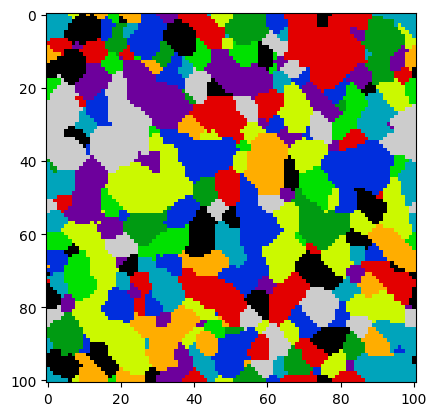

In [24]:
plt.figure()
plt.imshow(kr.tgset[5].s, cmap='nipy_spectral')

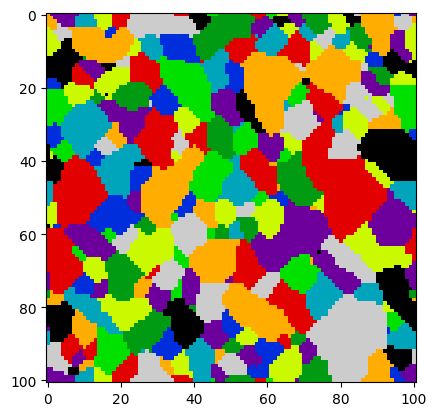

In [23]:
plt.figure()
plt.imshow(kr.sgset[5].s, cmap='nipy_spectral')